In [2]:
import pandas as pd
import re
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from langdetect import detect
except ImportError:
    !{sys.executable} -m pip install Sastrawi langdetect
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from langdetect import detect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ------------------------------ ------- 786.4/981.5 kB 4.8 MB/s eta 0:00:01
     ---------------------------------------- 981.5/981.5 kB 5.1 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993364 sha256=b20ae0413d190f0484570e0546c31ac0391ecd4e99dde91207bca1da79a94f69
  Stored in directory: c:\users\hanao\appdata\local\pip\cache\wheels\95\03\7d\59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##Data 1

In [3]:
data1 = pd.read_csv(r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\hoax-fake.csv", encoding='latin1', sep=';')

In [4]:
data1.head()

,Label,Headline,Body,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1,Pertamina dan Pemerintah Kalrifikasi Isu BBM N...,Foto: Kumparan.com Debunk ini berisi iKlarifik...,NaN,NaN,NaN,NaN
1,1,Polda Nusa Tenggara Barat Mengklarifkasi Bahwa...,Foto Ilustrasi Perkosaan Debunk ini berisi kla...,NaN,NaN,NaN,NaN
2,1,PT Ultrajaya Milk Industry Tbk Mengklarifikasi...,Debunk ini berisi klarifikasi dari PT Ultrajay...,NaN,NaN,NaN,NaN
3,1,BBKSDA Jatim Mengklarifikasi Bahwa Wisata Alam...,foto: tribunnews.com Debunk ini berisi Klrifik...,NaN,NaN,NaN,NaN
4,1,BMKG Mataram Menghimbau Agar Warga Tidak Langs...,Foto: tribunnews.com (Jokowi sedang memantau l...,NaN,NaN,NaN,NaN


In [5]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Label       1116 non-null   int64  
 1   Headline    1116 non-null   object 
 2   Body        1116 non-null   object 
 3   Unnamed: 3  0 non-null      float64
 4   Unnamed: 4  0 non-null      float64
 5   Unnamed: 5  0 non-null      float64
 6   Unnamed: 6  0 non-null      float64
dtypes: float64(4), int64(1), object(2)
memory usage: 61.2+ KB


In [6]:
data1.isnull().sum()

Label            0
Headline         0
Body             0
Unnamed: 3    1116
Unnamed: 4    1116
Unnamed: 5    1116
Unnamed: 6    1116
dtype: int64

In [7]:
data1 = data1.drop(columns=['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'])

In [8]:
data1.duplicated().sum()

1

In [9]:
data1 = data1.drop_duplicates()

In [10]:
data1 = data1[['Headline', 'Body', 'Label']]

In [11]:
data1.shape

(1115, 3)

In [12]:
data1['label'] = data1['Label'].map({
    1: 'valid',
    0: 'hoax'
})
data1 = data1.drop(columns=['Label'])

In [13]:
data1 = data1.rename(columns={
    'Headline': 'headline',
    'Body': 'article'
})

In [14]:
data1.head()

,headline,article,label
0,Pertamina dan Pemerintah Kalrifikasi Isu BBM N...,Foto: Kumparan.com Debunk ini berisi iKlarifik...,valid
1,Polda Nusa Tenggara Barat Mengklarifkasi Bahwa...,Foto Ilustrasi Perkosaan Debunk ini berisi kla...,valid
2,PT Ultrajaya Milk Industry Tbk Mengklarifikasi...,Debunk ini berisi klarifikasi dari PT Ultrajay...,valid
3,BBKSDA Jatim Mengklarifikasi Bahwa Wisata Alam...,foto: tribunnews.com Debunk ini berisi Klrifik...,valid
4,BMKG Mataram Menghimbau Agar Warga Tidak Langs...,Foto: tribunnews.com (Jokowi sedang memantau l...,valid


In [15]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1115 entries, 0 to 1115
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  1115 non-null   object
 1   article   1115 non-null   object
 2   label     1115 non-null   object
dtypes: object(3)
memory usage: 34.8+ KB


##Data 2

In [17]:
data2 = pd.read_csv(r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\clickbait.csv")

In [18]:
data2.head()

,headline,article,label,source,date,url
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701171/masuk-...
1,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701171/masuk-...
2,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701078/malays...
3,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701078/malays...
4,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,Bekasi - Seorang driver ojek online di Bekasi ...,clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701077/viral-...


In [19]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15288 entries, 0 to 15287
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  15288 non-null  object
 1   article   15239 non-null  object
 2   label     15288 non-null  object
 3   source    15288 non-null  object
 4   date      15288 non-null  object
 5   url       15288 non-null  object
dtypes: object(6)
memory usage: 716.8+ KB


In [20]:
data2.isnull().sum()

headline     0
article     49
label        0
source       0
date         0
url          0
dtype: int64

In [21]:
data2 = data2.dropna()

In [22]:
data2.duplicated().sum()

436

In [23]:
data2 = data2.drop_duplicates()

In [24]:
data2.duplicated().sum()

0

In [25]:
data2 = data2[['headline', 'article', 'label']]

In [26]:
data2.head()

,headline,article,label
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",non-clickbait
2,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,non-clickbait
4,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,Bekasi - Seorang driver ojek online di Bekasi ...,clickbait
6,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",Jakarta - Kementerian Sosial (Kemensos) menyal...,non-clickbait
8,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",Tangerang - Polisi menangkap pria berinisial J...,non-clickbait


In [27]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14803 entries, 0 to 15287
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  14803 non-null  object
 1   article   14803 non-null  object
 2   label     14803 non-null  object
dtypes: object(3)
memory usage: 462.6+ KB


#Merge

In [28]:
data = pd.concat([data1, data2], ignore_index=True)

In [29]:
data.head()

,headline,article,label
0,Pertamina dan Pemerintah Kalrifikasi Isu BBM N...,Foto: Kumparan.com Debunk ini berisi iKlarifik...,valid
1,Polda Nusa Tenggara Barat Mengklarifkasi Bahwa...,Foto Ilustrasi Perkosaan Debunk ini berisi kla...,valid
2,PT Ultrajaya Milk Industry Tbk Mengklarifikasi...,Debunk ini berisi klarifikasi dari PT Ultrajay...,valid
3,BBKSDA Jatim Mengklarifikasi Bahwa Wisata Alam...,foto: tribunnews.com Debunk ini berisi Klrifik...,valid
4,BMKG Mataram Menghimbau Agar Warga Tidak Langs...,Foto: tribunnews.com (Jokowi sedang memantau l...,valid


In [30]:
data['label'] = data['label'].replace({
    'non-clickbait': 'valid'
})

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15918 entries, 0 to 15917
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  15918 non-null  object
 1   article   15918 non-null  object
 2   label     15918 non-null  object
dtypes: object(3)
memory usage: 373.2+ KB


In [32]:
data.shape
data['label'].value_counts()

label
valid        9091
clickbait    6144
hoax          683
Name: count, dtype: int64

In [33]:
data.duplicated().sum()

1

In [34]:
data = data.drop_duplicates()

In [35]:
data.duplicated().sum()

0

#Preprocessing

In [36]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URL
    text = re.sub(r"@\w+", "", text)            # remove mention
    text = re.sub(r"#", "", text)               # remove hashtag symbol
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # remove angka & simbol
    text = re.sub(r"\s+", " ", text).strip()    # normalize whitespace
    return text

data['headline'] = data['headline'].apply(normalize)
data['article'] = data['article'].apply(normalize)

In [37]:
#buat fitur full text
data['full_text'] = data['headline'] + " " + data['article']

In [38]:
data[['full_text', 'label']].head()

,full_text,label
0,pertamina dan pemerintah kalrifikasi isu bbm n...,valid
1,polda nusa tenggara barat mengklarifkasi bahwa...,valid
2,pt ultrajaya milk industry tbk mengklarifikasi...,valid
3,bbksda jatim mengklarifikasi bahwa wisata alam...,valid
4,bmkg mataram menghimbau agar warga tidak langs...,valid


In [39]:
data.duplicated().sum()

8

In [40]:
data = data.drop_duplicates()
data.shape

(15909, 4)

In [41]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp"]
from collections import Counter

all_words = " ".join(data['full_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset:")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset:
Kata 'yg': muncul 961 kali
Kata 'tdk': muncul 130 kali
Kata 'dgn': muncul 76 kali
Kata 'hoax': muncul 1321 kali
Kata 'bkn': muncul 61 kali
Kata 'klo': muncul 9 kali
Kata 'tp': muncul 62 kali


In [42]:
slang_dict = {
    "yg": "yang",
    "tdk": "tidak",
    "dgn": "dengan",
    "hoax": "hoaks",
    "bkn": "bukan",
    "tp": "tapi",
    "klo": "kalau"
}

def formalize(text):
    words = str(text).split()
    return " ".join([slang_dict.get(w, w) for w in words])

data['full_text'] = data['full_text'].apply(formalize)

In [43]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp"]
all_words = " ".join(data['full_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset:")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset:
Kata 'yg': muncul 0 kali
Kata 'tdk': muncul 0 kali
Kata 'dgn': muncul 0 kali
Kata 'hoax': muncul 0 kali
Kata 'bkn': muncul 0 kali
Kata 'klo': muncul 0 kali
Kata 'tp': muncul 0 kali


In [45]:
factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()

path_lokal = r'C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\stopwords_id.txt'
with open(path_lokal, 'r') as f:
    lokal_stopwords = f.read().splitlines()

final_stopwords = list(set(sastrawi_stopwords + lokal_stopwords))
print(f"Total Stopwords yang digunakan: {len(final_stopwords)}")

Total Stopwords yang digunakan: 381


In [46]:
data.head()

,headline,article,label,full_text
0,pertamina dan pemerintah kalrifikasi isu bbm n...,foto kumparan com debunk ini berisi iklarifika...,valid,pertamina dan pemerintah kalrifikasi isu bbm n...
1,polda nusa tenggara barat mengklarifkasi bahwa...,foto ilustrasi perkosaan debunk ini berisi kla...,valid,polda nusa tenggara barat mengklarifkasi bahwa...
2,pt ultrajaya milk industry tbk mengklarifikasi...,debunk ini berisi klarifikasi dari pt ultrajay...,valid,pt ultrajaya milk industry tbk mengklarifikasi...
3,bbksda jatim mengklarifikasi bahwa wisata alam...,foto tribunnews com debunk ini berisi klrifika...,valid,bbksda jatim mengklarifikasi bahwa wisata alam...
4,bmkg mataram menghimbau agar warga tidak langs...,foto tribunnews com jokowi sedang memantau lok...,valid,bmkg mataram menghimbau agar warga tidak langs...


In [47]:
data['article_len'] = data['full_text'].apply(lambda x: len(str(x).split()))
display(data['article_len'].describe())

count    15909.000000
mean       268.581432
std        175.215340
min          5.000000
25%        175.000000
50%        235.000000
75%        312.000000
max       4403.000000
Name: article_len, dtype: float64

In [48]:
data['article_len'] = data['full_text'].apply(lambda x: len(str(x).split()))
data = data[(data['article_len'] >= 10) & (data['article_len'] <= 700)].copy()

print(f"Data tersisa: {len(data)} artikel")

Data tersisa: 15545 artikel


In [49]:
print(data['article_len'].describe())

count    15545.000000
mean       252.339337
std        112.765787
min         10.000000
25%        174.000000
50%        233.000000
75%        305.000000
max        700.000000
Name: article_len, dtype: float64


#Deteksi Bahasa

In [50]:
def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# sampling 1000 data biar cepat
sample_data = data.sample(1000, random_state=42)

sample_data['lang'] = sample_data['article'].apply(detect_lang)
sample_data['lang'].value_counts(normalize=True)

lang
id    1.0
Name: proportion, dtype: float64

In [52]:
data['lang'] = data['full_text'].apply(detect_lang)
data = data[data['lang'] == 'id']

In [53]:
data.shape

(15497, 6)

#Cek Target

In [54]:
data['label'].value_counts(normalize=True)

label
valid        0.572691
clickbait    0.388011
hoax         0.039298
Name: proportion, dtype: float64

In [55]:
data.groupby('label')['article_len'].mean()

label
clickbait    238.868951
hoax         243.331691
valid        262.503099
Name: article_len, dtype: float64

#Visualisasi

In [57]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15497 entries, 0 to 15917
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   headline     15497 non-null  object
 1   article      15497 non-null  object
 2   label        15497 non-null  object
 3   full_text    15497 non-null  object
 4   article_len  15497 non-null  int64 
 5   lang         15497 non-null  object
dtypes: int64(1), object(5)
memory usage: 847.5+ KB


In [58]:
data['label'].value_counts()
data['label'].value_counts(normalize=True)

label
valid        0.572691
clickbait    0.388011
hoax         0.039298
Name: proportion, dtype: float64

Dataset tersebut mencakup 15.506 entri berita yang dikelompokkan ke dalam kategori valid (57%), clickbait (39%), dan hoax (4%). Fitur utama yang digunakan adalah gabungan judul dan isi artikel yang telah melalui proses normalisasi serta pembersihan kata slang. Secara keseluruhan, data ini memiliki distribusi label yang tidak seimbang dengan mayoritas artikel berada pada rentang panjang 10 hingga 700 kata.  

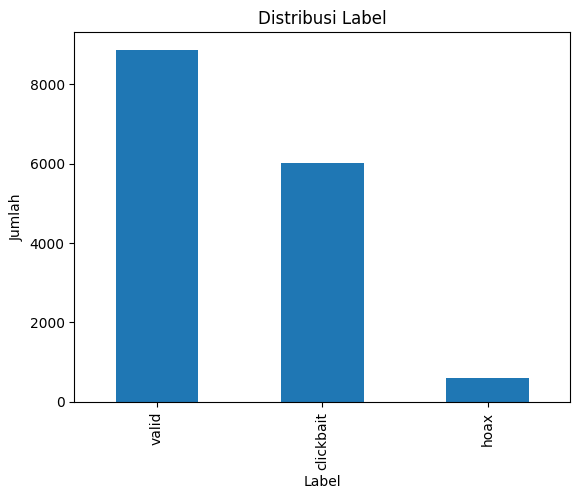

In [59]:
data['label'].value_counts().plot(kind='bar')
plt.title('Distribusi Label')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

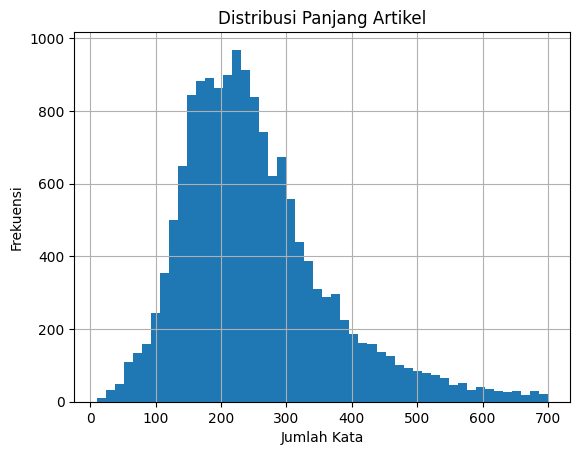

In [60]:
data['article_len'].hist(bins=50)
plt.title('Distribusi Panjang Artikel')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

Histogram tersebut memvisualisasikan distribusi panjang artikel dari 15.506 entri data setelah proses pembersihan outlier. Mayoritas artikel terkonsentrasi pada rentang 150 hingga 300 kata, dengan frekuensi tertinggi berada di sekitar 220-230 kata. Sejalan dengan batas best practice yang diterapkan, grafik menunjukkan pemotongan data secara tegas pada batas minimum 10 kata dan batas maksimum 700 kata.  

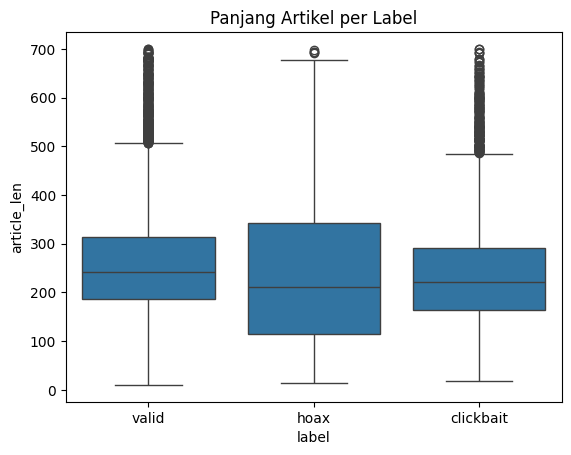

In [61]:
sns.boxplot(x='label', y='article_len', data=data)
plt.title('Panjang Artikel per Label')
plt.show()

Visualisasi boxplot tersebut menunjukkan bahwa artikel berlabel valid cenderung memiliki median panjang teks tertinggi, sementara artikel hoax memiliki variasi panjang yang paling lebar dibandingkan kategori lainnya. Meskipun mayoritas data terkonsentrasi pada rentang 150 hingga 300 kata, terdapat banyak data pencilan (outlier) di bagian atas pada ketiga kategori. Secara keseluruhan, distribusi ini mengonfirmasi bahwa setelah pembersihan, seluruh artikel berada dalam batas aman antara 10 hingga 700 kata.  

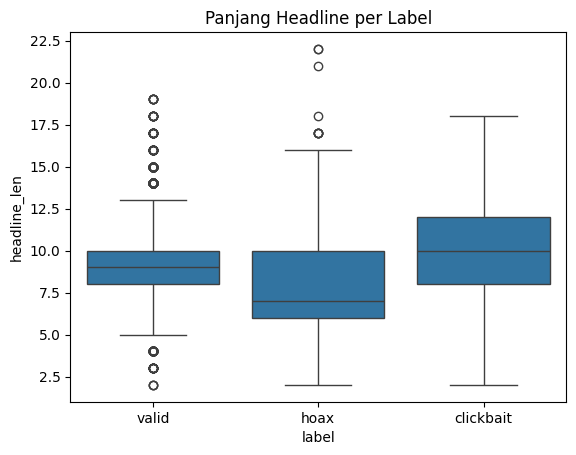

In [62]:
data['headline_len'] = data['headline'].str.split().apply(len)

sns.boxplot(x='label', y='headline_len', data=data)
plt.title('Panjang Headline per Label')
plt.show()

Berdasarkan grafik boxplot tersebut, artikel berlabel clickbait memiliki median panjang headline tertinggi dibandingkan kategori lainnya, yang mengindikasikan adanya kecenderungan penggunaan judul yang lebih panjang untuk menarik perhatian pembaca. Sebaliknya, artikel hoax menunjukkan median terendah dengan sebaran data yang cukup lebar ke arah judul yang sangat pendek maupun sangat panjang sebagai pencilan (outlier). Sementara itu, artikel valid memiliki distribusi panjang headline yang paling stabil dan terkonsentrasi, meskipun tetap ditemukan beberapa data pencilan ekstrem di kedua ujung rentang panjang katanya.  

In [63]:
def get_top_words_df(text_series, label_name, n=10):
    stop_list = list(final_stopwords)

    vec = CountVectorizer(stop_words=stop_list)
    X = vec.fit_transform(text_series)
    words = vec.get_feature_names_out()
    counts = X.sum(axis=0).A1

    df_temp = pd.DataFrame(sorted(zip(words, counts), key=lambda x: x[1], reverse=True)[:n],
                           columns=['word', 'count'])
    df_temp['label'] = label_name
    return df_temp

In [64]:
all_top_words = []
labels = data['label'].unique()

for label in labels:
    target_text = data[data['label'] == label]['full_text']
    top_words_df = get_top_words_df(target_text, label, n=10)
    all_top_words.append(top_words_df)

df_viz = pd.concat(all_top_words)

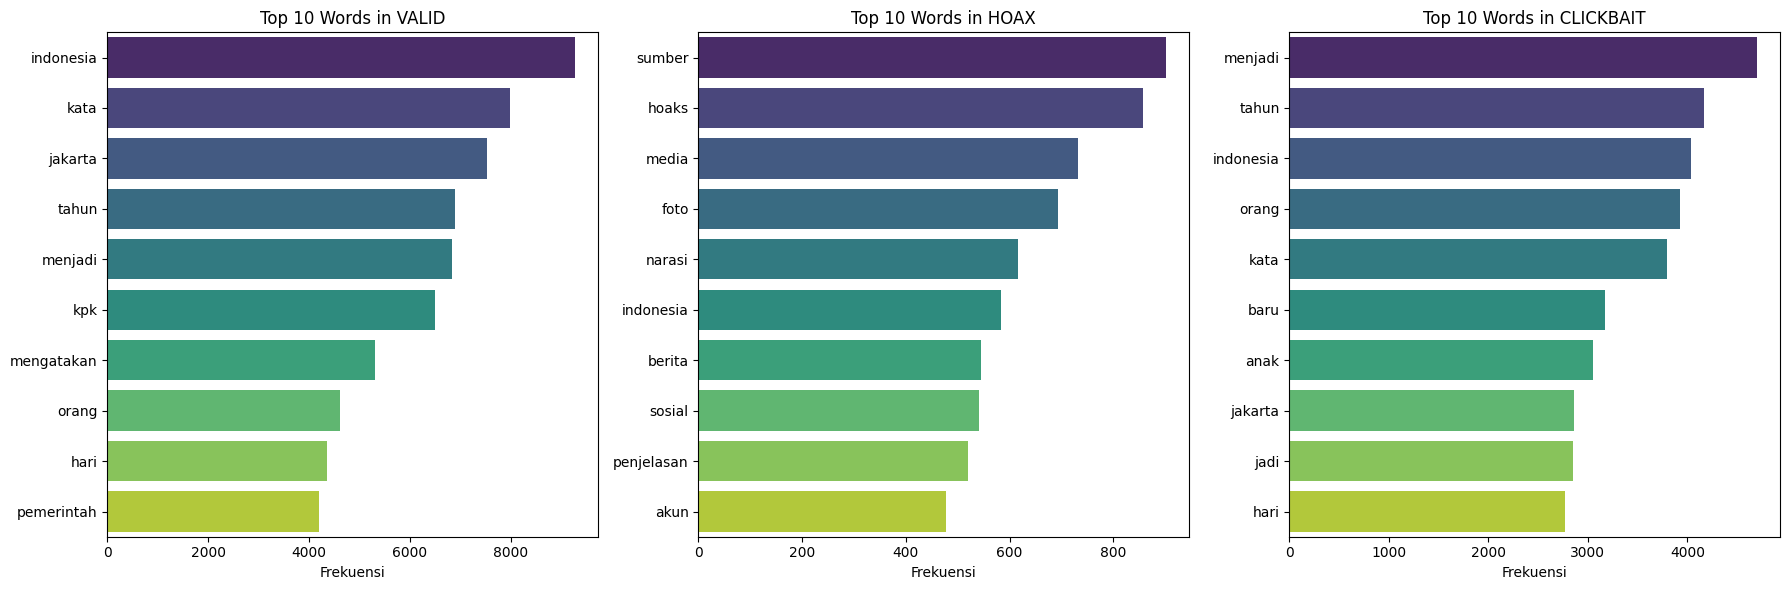

In [65]:
fig, axes = plt.subplots(1, len(labels), figsize=(18, 6), sharey=False)

for i, label in enumerate(labels):
    subset = df_viz[df_viz['label'] == label]
    sns.barplot(x='count', y='word', data=subset, ax=axes[i], palette='viridis', hue='word', legend=False)
    axes[i].set_title(f'Top 10 Words in {label.upper()}')
    axes[i].set_xlabel('Frekuensi')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Kata "tidak" menjadi kata yang paling dominan muncul di ketiga kategori, yang menunjukkan peran penting kata negasi ini baik dalam penyampaian fakta maupun penyebaran disinformasi. Pada kategori HOAX, muncul kata-kata kunci spesifik seperti "sumber", "hoax", "media", dan "narasi" yang merefleksikan karakteristik konten yang sering mempertanyakan validitas informasi atau membangun opini tertentu. Sementara itu, kategori VALID dan CLICKBAIT berbagi banyak kosa kata umum seperti "indonesia", "jakarta", "tahun", dan "hari", namun kategori valid memiliki frekuensi kata yang jauh lebih tinggi dibandingkan kategori lainnya.  

In [66]:
data['lang'].value_counts(normalize=True)

lang
id    1.0
Name: proportion, dtype: float64

Data tersebut menunjukkan bahwa seluruh artikel dalam dataset (100% atau proporsi 1.0) telah berhasil difilter dan divalidasi sebagai artikel berbahasa Indonesia (id). Hal ini memastikan bahwa fitur-fitur teks yang dihasilkan dalam proses preprocessing selanjutnya akan bersifat homogen dan relevan dengan kosa kata bahasa Indonesia.  

##Encoding

In [68]:
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])

print("Mapping Label Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

print("\nValue Counts of Encoded Labels:")
print(data['label'].value_counts())

Mapping Label Encoding:
clickbait: 0
hoax: 1
valid: 2

Value Counts of Encoded Labels:
label
2    8875
0    6013
1     609
Name: count, dtype: int64


#Save data

In [70]:
# Simpan hanya kolom yang diperlukan untuk training
data_final = data[['full_text', 'label']]
data_final.to_csv(r'C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\final\final-data-hoax.csv', index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!
